# **PHASE 1** 
- **1. 데이터 선정**
- 1.1. 문제 설정: 미국 인구 조사 데이털르 기반으로 age, workclass, marital-status 등을 활용해 소득 수준(50K 이상/미만) 예측
- 1.2.데이터 선정 :DATASET: https://archive.ics.uci.edu/dataset/2/adult 
- number of instance: 48,842
- number of Feature : 14 
- **2. 문제 설정 및 과제 설계**
- 문제 설정: 개인 정보를 기반으로 소득이 50K 이상인지 예측하는 supervised classification. 
- 현재 사용 현황: Xgboost, SVM, Random Forest, NN, Logistic Regression 등을 이용해 acc 최소 78~최대 87 정도의 성능을 낸다. 
- 기계학습 모델: SVM, Random Forest, MLP, Logistic regression, KNN 등을 사용하여 전처리된 data를 학습한다. 
- 성능지표
- Accuracy: 전체 중 label을 정확히 예측한 비율. 직관적 성능 평가
- F1-score: 불균형 label을 고려한 precsion-recall의 조화평균. 
- AUC-ROC: 전반적인 threshold에 대해 모델의 분류 능력 평가
- Adult dataset은 50K 아래가 많은 다소 불균형한 dataset이기 불균형한 상황에서도 모델 성능을 잘 반영하는 F1-score, ROC-AUC를 선택했다. 
- 최소 성능 : [acc>75%, f1>0.70,auc-roc>0.80]

# **PHASE 2**
- 3. 데이터 탐색 및 분석 (EDA) (권장: 랜덤 시드 설정, 데이터 복사하여 사용)
- 3.1 Adult dataset의 feature은 미국 인구를 대상으로 진행한 age, work-class 등을 포함한다. 총 총 14개의 feature과 48,842개의 instance를 갖는다. 
- 범주형(categorical): workclass, education, marital-status, occupation, relationship, race, sex, native-country 
- 수치형(numerical): age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week

In [34]:
# imports and setups
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# 실행 결과를 일정하게 유지하기 위해 랜덤 시드를 설정:
np.random.seed(42)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
np.set_printoptions(precision=2, suppress=True)

- 3.2. 데이터셋의 각feature를 조사:  
• 데이터 결측치, 이상치 확인  
• 데이터 분포 시각화 및 분석  
• feature 간 상관관계  
• feature 별 적용할 전처리 결정  

In [35]:
import pandas as pd

# UCI Adult 데이터셋 raw 파일 URL
url_data = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
url_test = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

# 컬럼명 정의 (adult.names 파일 참고해서 지정)
column_names = ["age","workclass","fnlwgt","education","education-num",
                "marital-status","occupation","relationship","race","sex",
                "capital-gain","capital-loss","hours-per-week","native-country","income"]

# train 데이터 로드
df_train = pd.read_csv(url_data, names=column_names, sep=',', skipinitialspace=True)

# test 데이터 로드 (첫 줄이 헤더가 아니라 주석 포함이므로 skiprows=1 권장)
df_test = pd.read_csv(url_test, names=column_names, sep=',', skipinitialspace=True, skiprows=1)

print(df_train.shape, df_test.shape)
df_train.head()

(32561, 15) (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [9]:
df_train.info() #모든 non-null feature 16281개 결측치 없음.
#df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


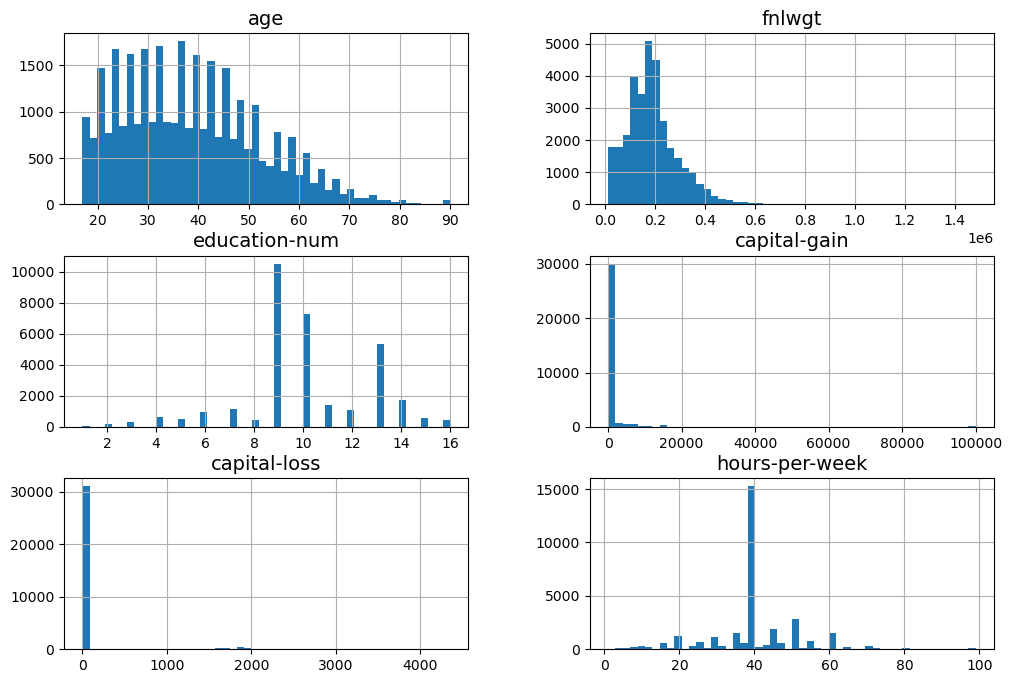

In [10]:
df_train.hist(bins=50,figsize=(12,8))
plt.show()
#age는 20대~50세 구간에 대부분 분포함. right-skewed 분포이다->표준화 혹은 min-max 가능.
#fnlwgt: 0~0.3 구간에 밀집되어 있고 극단적으로 큰 값이 일부 존재한다. 이상치처럼 보이지만 실제로 의미 있는 값이므로 제거하지 않는다. ->로그 변환 가능
#education-num: 이산적인 정수값으로 특정 값(9,10,13)에 빈도가 몰린다. ->이미 categorical을 ordinal 형태로 변환한 값이므로 스케일링 불필요
#capital-gain/capital loss: 대게 0이나 극단적으로 큰 값이 일부 존재. 이상치 아니므로 제거 X 
#->특정 threshold 기준으로 0/1 이진화  +capital gain과 loss의 상관관계를 살펴볼만하다
#hours-per-week : 40hours에 가장 큰 spike. 나머지 범위도 고르게 분포함 -> 표준화 or 범주화

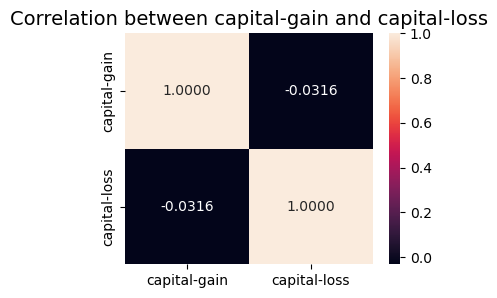

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

corr = df_train[['capital-gain', 'capital-loss']].corr()

plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, fmt=".4f")
plt.title("Correlation between capital-gain and capital-loss")
plt.show()

#capital-gain과 loss가 관련 있을거라 추론했지만 결과는 거의 무관(상관계수 절댓값 0.0316)하게 나온다
#capital gain은 투자, 자산 처분으로 얻는 이득/loss는 세금 관련 공제이기 때문
#--> feature selection 시 둘 중 하나를 제거해도 거의 영향이 없음을 알 수 있다.


In [12]:
df_train["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

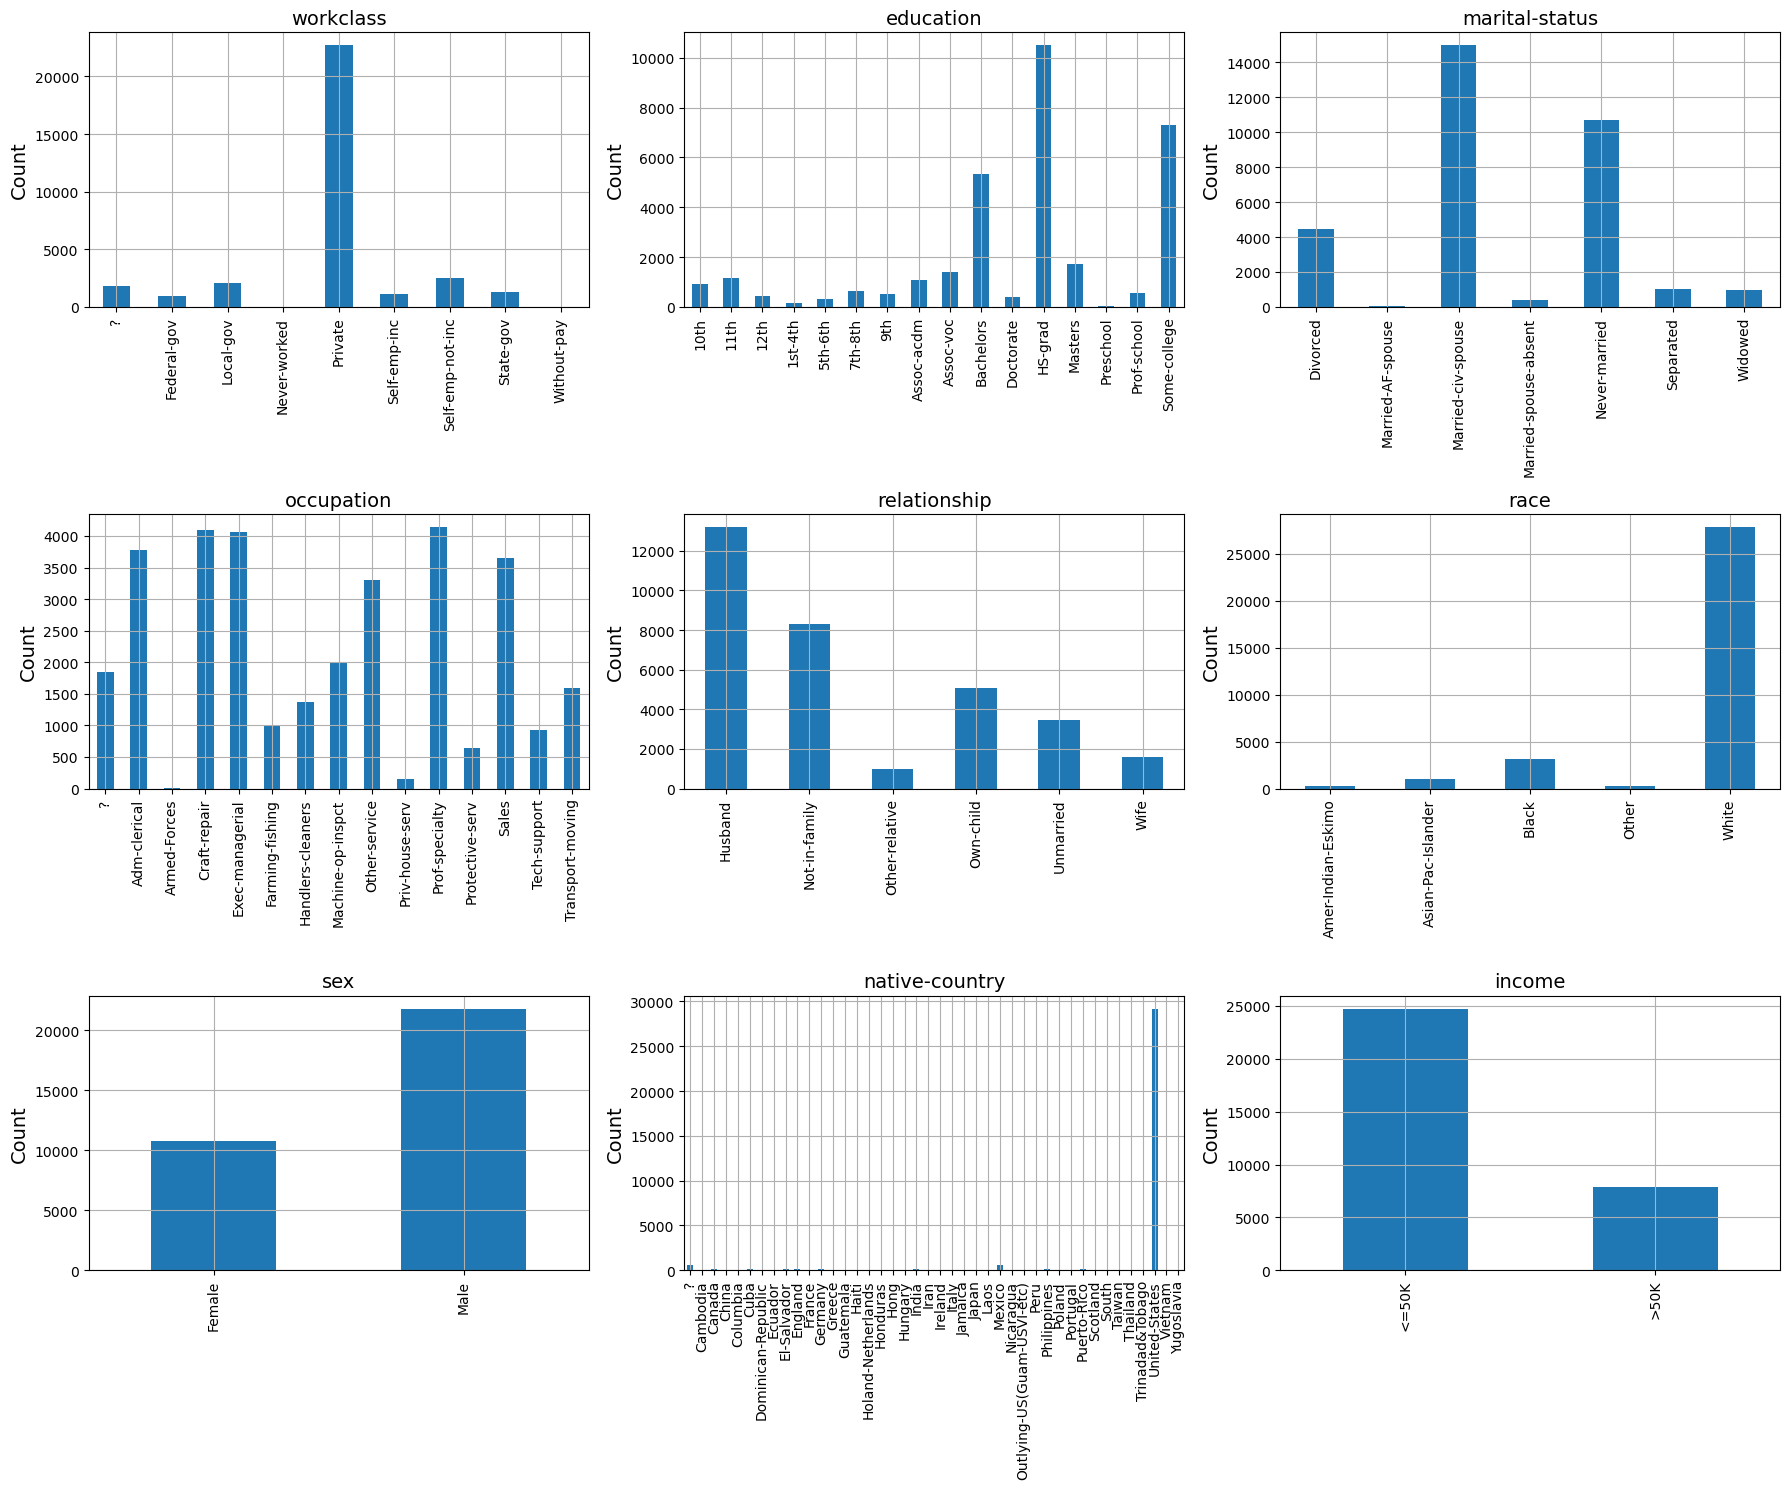

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

cat_features = df_train.select_dtypes(include=['object']).columns

n = len(cat_features)
rows = (n + 2) // 3
cols = 3

plt.figure(figsize=(18, 5 * rows))

for idx, col in enumerate(cat_features, 1):
    plt.subplot(rows, cols, idx)
    df_train[col].value_counts().sort_index().plot.bar(grid=True)
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

#workclass: “Private”가 가장 많고 일부 “Self-emp”, “State-gov”, “Federal-gov” 존재, “?” 일부 존재 → missing 처리 필요, one-hot 인코딩 가능
#education: “HS-grad”, “Some-college”, “Bachelors”가 빈도 높음, rare class 존재 → one-hot 인코딩, rare class는 “others”로 묶기 가능
#marital-status: “Married-civ-spouse” > “Never-married” 순, 결혼 여부가 income과 상관 가능 → binary(기혼/비기혼) 축약 가능
#occupation: Exec-managerial, Prof-specialty에 샘플 집중, “?” 값 존재 → missing 처리 필요, one-hot 인코딩 시 차원 증가, 필요 시 직군 grouping(white/blue-collar)
#relationship: “Husband”, “Not-in-family”, “Own-child” 주류 → one-hot 인코딩 적합, feature importance에서 유의미 가능
#race: “White” 압도적, “Black”, “Asian-Pac-Islander” 등 소수 → 모델 편향 가능성 주의, one-hot 인코딩 가능
#sex: Male > Female → binary encoding 0/1 간단 적용
#native-country: 대부분 “United-States”, 나머지 희소 → one-hot 시 sparse + noise, binary(US/Other) 혹은 feature selection에서 제외.
#income (target): “<=50K” 약 2/3, “>50K” 적음 → 클래스 불균형 존재, stratified split, 평가 시 F1-score/ROC-AUC 

# 수치형 vs 수치형 feature 간 상관관계 분석
- 정규 corr() 사용
# 범주형 vs 수치형 feature 간 상관관계 분석
- one-hot 후 dummy 별 point-biserial -> 가장 강한 상관만 추출
- 범주형-수치형의 비선형적 효과도 어느정도 반영
# 범주형 vs 범주형 feature 간 상관관계 분석
- chi-square 기반 Carmér's V 계산

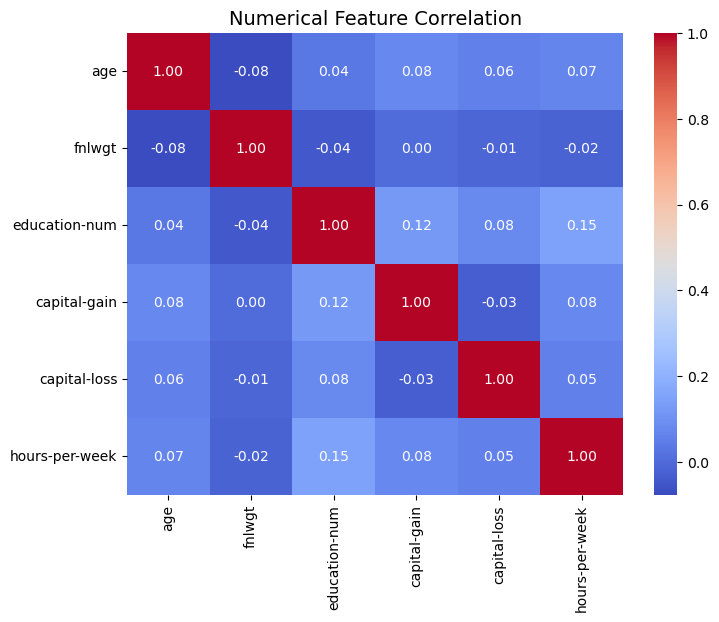


-Numerical vs Numerical Correlation-
                     age    fnlwgt  education-num  capital-gain  capital-loss  \
age             1.000000 -0.076646       0.036527      0.077674      0.057775   
fnlwgt         -0.076646  1.000000      -0.043195      0.000432     -0.010252   
education-num   0.036527 -0.043195       1.000000      0.122630      0.079923   
capital-gain    0.077674  0.000432       0.122630      1.000000     -0.031615   
capital-loss    0.057775 -0.010252       0.079923     -0.031615      1.000000   
hours-per-week  0.068756 -0.018768       0.148123      0.078409      0.054256   

                hours-per-week  
age                   0.068756  
fnlwgt               -0.018768  
education-num         0.148123  
capital-gain          0.078409  
capital-loss          0.054256  
hours-per-week        1.000000  


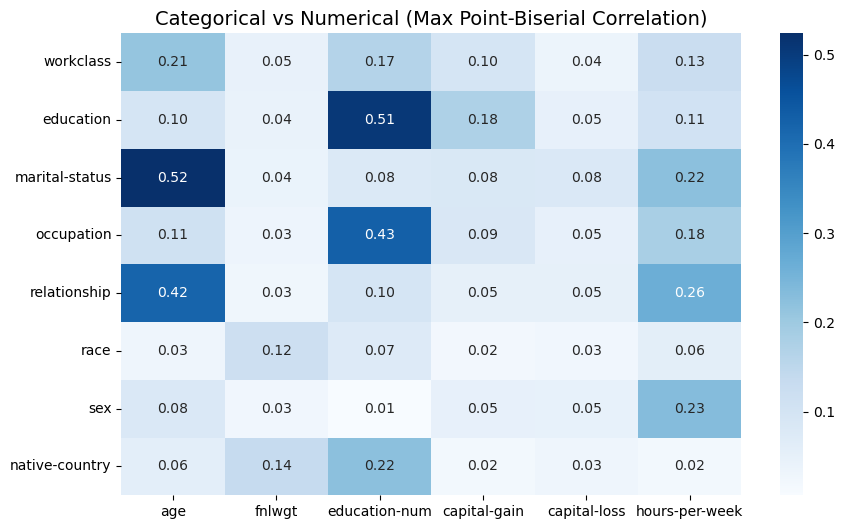


- Categorical vs Numerical (Point-biserial max per category) -
                     age    fnlwgt education-num capital-gain capital-loss  \
workclass       0.210491  0.046589      0.165069     0.096482     0.036377   
education       0.096392  0.042841      0.505892     0.176064     0.049306   
marital-status  0.524003  0.038584      0.080737     0.084317     0.081367   
occupation      0.111367  0.033831      0.427039     0.086308     0.049125   
relationship    0.420621   0.02676      0.096893      0.05235     0.050834   
race            0.032347  0.118521      0.074339     0.021117     0.026197   
sex             0.081993  0.025362      0.006157     0.048814     0.047011   
native-country  0.057492  0.136919      0.223524     0.019569     0.030146   

               hours-per-week  
workclass            0.126254  
education            0.106704  
marital-status       0.223621  
occupation           0.182292  
relationship          0.26371  
race                 0.060463  
sex      

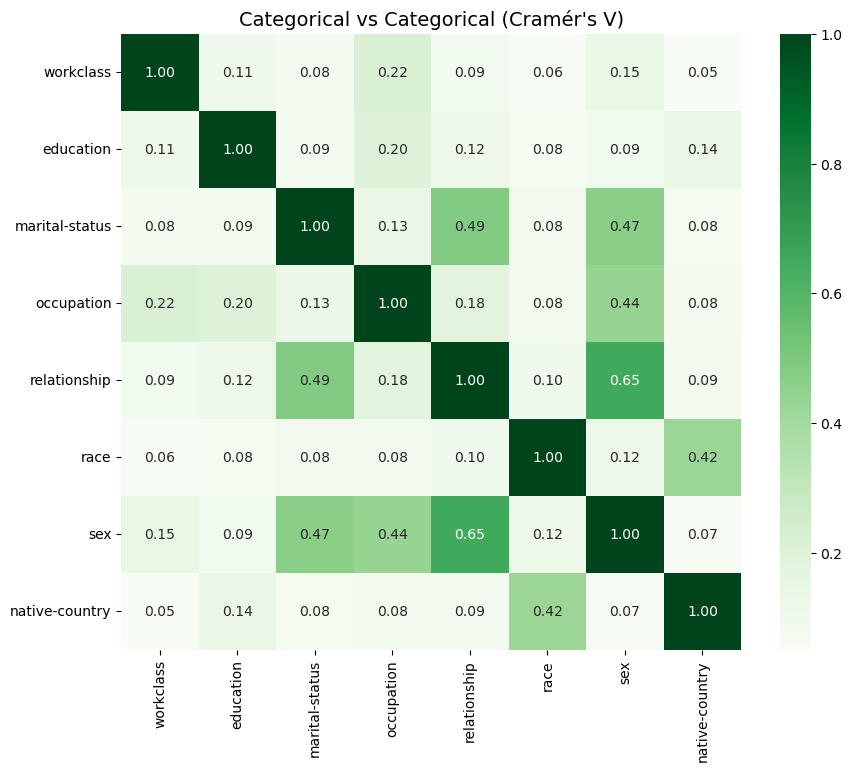


-Categorical vs Categorical Correlation (Cramér's V)-
               workclass education marital-status occupation relationship  \
workclass            1.0   0.10984       0.077296   0.217152     0.089218   
education        0.10984       1.0       0.086815   0.197914     0.117786   
marital-status  0.077296  0.086815            1.0    0.13209     0.487194   
occupation      0.217152  0.197914        0.13209        1.0     0.178738   
relationship    0.089218  0.117786       0.487194   0.178738          1.0   
race             0.05746  0.075492       0.083689   0.083713     0.097071   
sex             0.145009  0.091077       0.466126   0.435359     0.650262   
native-country   0.05079  0.136777       0.075262   0.077057     0.087208   

                    race       sex native-country  
workclass        0.05746  0.145009        0.05079  
education       0.075492  0.091077       0.136777  
marital-status  0.083689  0.466126       0.075262  
occupation      0.083713  0.435359       0.

In [36]:
#수치형 feature 간 상관 관계 추가 분석 -> 유의미한 상관관계 없음
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

# 데이터 불러오기
#df = pd.read_csv(url_data, names=column_names, sep=',\s*', engine='python')

df = df_train.copy()
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.strip()

# '?' 값은 NaN으로 처리
df.replace("?", pd.NA, inplace=True)

#수치형 컬럼 상관계수
num_cols = ["age","fnlwgt","education-num","capital-gain","capital-loss","hours-per-week"]
cat_cols = [
    "workclass","education","marital-status","occupation",
    "relationship","race","sex","native-country"
]
df = df.dropna(subset=cat_cols)

corr_matrix = df_train[num_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Numerical Feature Correlation")
plt.show()
#print("수치형 상관계수:\n", corr_matrix)
print("\n-Numerical vs Numerical Correlation-")
print(corr_matrix)


#수치형과 범주형 상관관계 (point-biserial)
# income을 0/1 이진값으로 변환
df["income_bin"] = (df["income"] == ">50K").astype(int)

cat_num_corr = pd.DataFrame(index=cat_cols, columns=num_cols)

for cat in cat_cols:
    for num in num_cols:
        # 범주형을 one-hot으로 변환 후 가장 정보량이 큰 dummy 사용
        dummies = pd.get_dummies(df[cat], drop_first=True)
        # 각 dummy와 수치형의 point-biserial 계산 → 최대값 사용
        vals = []
        for col in dummies.columns:
            try:
                corr, _ = pointbiserialr(dummies[col], df[num])
                vals.append(abs(corr))
            except:
                continue
        cat_num_corr.loc[cat, num] = max(vals) if vals else np.nan

plt.figure(figsize=(10,6))
sns.heatmap(cat_num_corr.astype(float), annot=True, cmap="Blues", fmt=".2f")
plt.title("Categorical vs Numerical (Max Point-Biserial Correlation)")
plt.show()

print("\n- Categorical vs Numerical (Point-biserial max per category) -")
print(cat_num_corr)

# 범주형 feature 상관관계 
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

cat_cat_corr = pd.DataFrame(index=cat_cols, columns=cat_cols)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cat_cat_corr.loc[c1, c2] = 1.0
        else:
            try:
                cat_cat_corr.loc[c1, c2] = cramers_v(df[c1], df[c2])
            except:
                cat_cat_corr.loc[c1, c2] = np.nan

plt.figure(figsize=(10,8))
sns.heatmap(cat_cat_corr.astype(float), annot=True, cmap="Greens", fmt=".2f")
plt.title("Categorical vs Categorical (Cramér's V)")
plt.show()

print("\n-Categorical vs Categorical Correlation (Cramér's V)-")
print(cat_cat_corr)


# **상관 관계 분석**
# 수치형 feature 간의 상관은 대체로 낮다(<0.2)
# 수치형 feature & 범주형 feature 간의 상관관계
- **marital-status** → age (0.52), hours-per-week(0.22), capital-gain(0.08)
기혼 여부가 노동시간 및 경제적 성취에 강한 영향을 미침
- **relationship** → **age(0.42)**, hours-per-week(0.26)
가구 내 역할(가장/부양가족 여부)이 직업 패턴에 중요한 
- education → education-num(0.50)
당연한 구조적 상관. 둘 중 하나만 선택
- **occupation** → **education-num(0.43)**, hours-per-week(0.18)
직업군은 확실한 socio-economic 지표
# 범주형 feature 간의 상관 관계
- **relationship** , **sex** (0.65)로 가장 높은 상관관계 그외 maritial-status&relationship(0.49), race&native country(0.42)의 상관관계가 높았다.
- maritial-status&relationship는 중복된 정보이므로 하나만 선택, sex도 relation과 높은 상관이 있으나 income과 직접적으로 관계가 강한 변수로 추론되므로 유지

# phase2-4. 데이터 전처리
- 범주형 feature 변환(one-hot encoding)
- feature 스케일링(표준화, 로그변환 등)
- 연속형 범주 이산화
- 파이프라인 구축 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

In [42]:
#df_train, df_test 모두 적용해야하므로 함수화 

#edcation feature 그룹화 -> 새 cat feature
def map_education_level(df):
    low = ["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th"]
    middle = ["HS-grad", "Some-college", "Assoc-acdm", "Assoc-voc"]
    high = ["Bachelors", "Masters", "Doctorate", "Prof-school"]
    
    df = df.copy()
    df["education-level"] = df["education"].apply(
        lambda x: "low" if x in low else
                  "middle" if x in middle else
                  "high"
    )
    return df

# occupation feature 그룹화 -> 새 cat feature
def map_occupation_group(df):
    mapping = {
        "Exec-managerial": "white-collar",
        "Prof-specialty": "professional",
        "Adm-clerical": "white-collar",
        "Sales": "white-collar",
        "Craft-repair": "blue-collar",
        "Transport-moving": "blue-collar",
        "Handlers-cleaners": "blue-collar",
        "Machine-op-inspct": "blue-collar",
        "Tech-support": "service",
        "Protective-serv": "service",
        "Other-service": "service",
        "Farming-fishing": "blue-collar",
        "Armed-Forces": "military",
        "?": "unknown"
    }
    df = df.copy()
    df["occupation-group"] = df["occupation"].apply(lambda x: mapping.get(x, "other"))
    return df

#로그
def log_transform(df):
    df = df.copy()
    df["fnlwgt"] = np.log1p(df["fnlwgt"])
    df["capital-gain"] = np.log1p(df["capital-gain"])
    df["capital-loss"] = np.log1p(df["capital-loss"])
    return df

def has_capgain(df):
    df["has_capital_gain"] = (df["capital-gain"] > 0).astype(int)
    return df

def replaceNan(df):
    df.replace('?', pd.NA, inplace=True)
    return df

def custom_feature_engineering(df):
    df = df.copy()
    df = log_transform(df)
    df = map_education_level(df)
    df = map_occupation_group(df)
    df = has_capgain(df)
    df = replaceNan(df)
    df = df.drop(columns=["native-country"],errors='ignore') # native-country 제거
    #df = df.drop(columns=["education-num"],errors='ignore') #앞선 feature 간 상관관계에서 education과 중복된 정보이므로 drop
    df.replace("?", pd.NA, inplace=True)
    return df

# # # # # - - feature engineering 적용 - - # # # # # 
# 새 카테고리 생성, 로그 변환
df_train_eng = custom_feature_engineering(df_train)
df_test_eng  = custom_feature_engineering(df_test)

#target을 binary로 변환
df_train_eng['income'] = df_train['income'].apply(lambda x: 1 if x.strip()=='>50K' else 0)
df_test_eng['income'] = df_test['income'].apply(lambda x: 1 if x.strip()=='>50K' else 0)

In [43]:
num_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
]
cat_features = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex",
    "education-level", "occupation-group", "has_capital_gain"   # 새로 만든 feature        
]

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# 수치형 파이프라인
num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# 범주형 파이프라인
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent",fill_value="Missing"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False))

# 최종 ColumnTransformer
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])


# Phase2-5. 여러가지 모델 실험
# 5-1. 1개 이상의 앙상블 모델을 포함한 총 5개의 모델 선택
- Bagging classifier, RandomForest, SVM, Logistic Regression, MLP_classifier: classification 문제에서 좋은 성과를 내는 모델 5개를 선정하였다. 앙상블 모델과 일반 모델 간의 비교를 위해 Bagging classifier, Random Forest 두 개의 앙상블 모델을 선택하였다. 
- Bagging (DecisionTree): 단일 트리의 불안정성을 줄이고 안정적인 예측 성능 확인
- RandomForest: Bagging 기반이면서 feature subsampling을 통한 일반화 능력 향상
- SVM (RBF kernel): 비선형 decision boundary 확인, 마진 기반 분류 성능 평가
- Logistic Regression: 기본 선형 모델로 baseline 제공, 확률 예측 평가 가능
- MLP Classifier: 단층 신경망을 통한 비선형 패턴 학습 능력 확인

# 5-2. CV 성능을 측정하고 비교 및 분석
- 불균형 문제를 완화하기 위해 StratifiedKFold를 사용하였다. 
- 성능 지표는 위에서 정한 accuracy, f1, roc_auc를 사용하였다

In [44]:
import pandas as pd
import numpy as np

# 모델: Bagging classifier, RandomForest, SVM, Logistic Regression, MLP_classifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# 전처리 및 평가
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# 1. df_train, df_test에서 X, y 분리
# target column은 'income' 
X_train = df_train_eng.drop("income", axis=1)
y_train = df_train_eng["income"]

X_test = df_test_eng.drop("income", axis=1)
y_test = df_test_eng["income"]

# 1-1. 형식오류 방지
for col in cat_features:
    X_train[col] = X_train[col].astype("string")
    X_test[col] = X_test[col].astype("string")

# 2. 수치형/범주형 컬럼 지정
num_cols = ["age","fnlwgt","education-num","capital-gain",
            "capital-loss","hours-per-week"]

# 나머지는 범주형
cat_cols = [col for col in X_train.columns if col not in num_cols]


# 3. 전처리 파이프라인
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])


# 4. 사용할 5개 모델 정의
models = {
    "Bagging": BaggingClassifier(tree.DecisionTreeClassifier()),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "LogisticRegression": LogisticRegression(max_iter=500),
    "MLP": MLPClassifier(max_iter=500)
}


# 5. Stratified K-Fold CV 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 사용할 성능 지표
scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = {}
 
# 6. 모델별 CV 실행

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("clf", model)
    ])
    
    cv_result = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=False
    )
    
    results[name] = {
        "accuracy_mean": np.mean(cv_result["test_accuracy"]),
        "f1_mean": np.mean(cv_result["test_f1"]),
        "roc_auc_mean": np.mean(cv_result["test_roc_auc"])
    }

# 7. result
print("=== 5-Fold Stratified CV Results ===")
for name, scores in results.items():
    print(f"\n[{name}]")
    for metric, value in scores.items():
        print(f"{metric}: {value:.4f}")


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\magic\anaconda3\envs\hannah924\Lib\site-packages\sklearn\utils\_encode.py", line 183, in _unique_python
    uniques = sorted(uniques_set)
              ^^^^^^^^^^^^^^^^^^^
  File "missing.pyx", line 392, in pandas._libs.missing.NAType.__bool__
TypeError: boolean value of NA is ambiguous

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\magic\anaconda3\envs\hannah924\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\magic\anaconda3\envs\hannah924\Lib\si

# baseline 모델 cv 성능 비교 분석
# 지표 별 성능 분석
* Accuracy 기준: 전체 샘플 기준 올바르게 예측한 비율. 데이터셋의 클래스 불균형 문제로 acc가 높아도 F1 score가 낮을 수 있다. -SVM이 가장 높음(0.8560), MLP가 가장 낮음(0.8350)
* F1-score 기준: minority class(>50k)에 대한 성능을 반영한다. RandomForest가 가장 높음(0.6730), 클래스 불균형을 일부 고려한 평가에서 Bagging과 MLP보다 안정적
* ROC-AUC 기준: 클래스 예측 순위 기반 평가. Logistic Regression이 가장 높음(0.9080), linear decision boundary로도 분류 성능이 뛰어남

# 앙상블 모델 비교:
* Bagging과 RandomForest는 모두 ensemble 기반이지만, RandomForest가 feature sub-sampling 덕분에 Bagging보다 F1-score와 ROC-AUC가 더 높음
단일 트리 기반 Bagging은 안정적이지만 feature correlation이 많은 데이터에서는 RandomForest보다 다소 낮은 성능
# 그 외 모델:
* SVM은 RBF kernel로 비선형 패턴을 학습했으나 F1-score에서 RandomForest를 약간 밑돌음
* Logistic Regression은 linear 모델이지만 ROC-AUC가 가장 높아, 클래스 간 순위 예측에는 강점
* MLP Classifier: MLP는 max_iter=500, 기본 파라미터만 사용했을 때 가장 낮은 Accuracy와 F1-score지만 데이터셋 크기 대비 네트워크 구조가 단순하고 초기화에 따라 성능 편차 발생 가능 염두.

# 결론
- RandomForest와 Logistic Regression이 전반적으로 안정적인 성능을 보이며, ensemble과 linear 모델 각각의 장점을 확인

Bagging은 안정적이지만 feature correlation이 많은 데이터에서는 RandomForest 대비 약간 낮음

SVM은 Accuracy가 높지만 F1-score에서 RandomForest를 밑돌아, 불균형 데이터에서는 민감도 차이가 존재

MLP는 기본 파라미터로 학습 시 성능이 가장 낮고, hyperparameter tuning 및 네트워크 구조 개선이 필요

불균형 데이터에서는 RandomForest 또는 Logistic Regression 기반 ensemble + threshold tuning이 효과적으로 보임

MLP는 하이퍼파라미터 조정과 학습률, 은닉층 수 등을 조정하면 성능 개선 가능

# Phase2-5.3. feature selection 기법을 적용 후 비교 분석
- feature selection method: 이전 feature 간 상관관계에서 feature 간의 dependency 경향이 미미한 것을 고려하여 feature 간의 독립적인 관계를 바탕으로 top-k feature를 선정하는 filtering 방법을 선택하였다. 
- 구체적인 algorithm으로, Mutual Information(MI)와 ANOVA F-Test을 사용한다. MI는 수치형, 범주형 feature 모두 처리 가능하고 non-linear 관계도 파악 가능하기에 채택했다. 수치형에 빠르게 적용 가능한 ANOVA F-test도 함께 사용하여 top-K feature을 추출한다.

In [19]:
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np
import pandas as pd

def filter_select_features(X, y, K=15):
    X_encoded = X.copy()
    
    # 타입별 컬럼 분리
    numeric_cols = X_encoded.select_dtypes(include=[np.number]).columns
    cat_cols = X_encoded.select_dtypes(include=["object", "string", "category"]).columns
    
    # 결측치 임시 처리
    for col in numeric_cols:
        X_encoded[col] = X_encoded[col].fillna(X_encoded[col].median())
    for col in cat_cols:
        X_encoded[col] = X_encoded[col].fillna("Missing")

    # 인코딩 (MI 계산용)
    for col in cat_cols:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    
    # 1. Mutual Information 계산
    mi_scores = mutual_info_classif(X_encoded, y, random_state=42)
    mi_series = pd.Series(mi_scores, index=X_encoded.columns)

    # 2. ANOVA F-Test 계산 (수치형만)
    f_series = pd.Series(dtype=float)
    if len(numeric_cols) > 0:
        f_scores, _ = f_classif(X_encoded[numeric_cols], y)
        f_series = pd.Series(f_scores, index=numeric_cols)

    # 3. 점수 스케일링 (0~1 범위로 정규화)
    scaler = MinMaxScaler()
    
    # MI 정규화
    mi_scaled = pd.Series(
        scaler.fit_transform(mi_series.values.reshape(-1, 1)).flatten(), 
        index=mi_series.index
    )
    
    # F-score 정규화
    f_scaled = pd.Series(dtype=float)
    if not f_series.empty:
        f_scaled = pd.Series(
            scaler.fit_transform(f_series.values.reshape(-1, 1)).flatten(), 
            index=f_series.index
        )

    # 4. 점수 결합 (평균)
    combined_score = pd.Series(dtype=float)
    
    for col in X_encoded.columns:
        score_mi = mi_scaled[col]
        
        if col in f_scaled.index:
            score_f = f_scaled[col]
            combined_score[col] = (score_mi + score_f) / 2  # 수치형: (MI + F) / 2
        else:
            combined_score[col] = score_mi  # 범주형: MI 점수 그대로 사용

    # 결과 정렬 및 상위 K개 선택
    combined_score = combined_score.sort_values(ascending=False)
    selected_features = combined_score.head(K).index.tolist()

    print(f"\n[Top {K} Selected Features]")
    print(combined_score.head(K))

    return selected_features

# ---------------------------------------------------------
# 실행
X_train = df_train_eng.drop("income", axis=1)
y_train = df_train_eng["income"]
X_test = df_test_eng.drop("income", axis=1)
y_test = df_test_eng["income"]

# 형식 오류 방지
for col in cat_features:
    X_train[col] = X_train[col].astype("string")
    X_test[col] = X_test[col].astype("string")

selected_cols = filter_select_features(X_train, y_train, K=11)

X_train_sel = X_train[selected_cols].copy()
X_test_sel  = X_test[selected_cols].copy()


[Top 11 Selected Features]
relationship        1.000000
marital-status      0.938277
capital-gain        0.856447
age                 0.592805
education           0.541458
occupation          0.536239
education-level     0.493202
hours-per-week      0.450301
occupation-group    0.266359
capital-loss        0.249486
has_capital_gain    0.227983
dtype: float64


occupation과 occupation-group는 중복되는 정보지만 점수가 크게 차이남(0.3 가량) -> 새 feature occupation-group이 학습을 저하할 수 있다고 판단, occupation만 선택.

In [17]:
X_train_sel = X_train_sel.drop(columns=["occupation-group"])
X_test_sel = X_test_sel.drop(columns=["occupation-group"])

In [33]:
import pandas as pd
import numpy as np

# 모델: Bagging classifier, RandomForest, SVM, Logistic Regression, MLP_classifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# 전처리 및 평가
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- X_train_sel로 train 진행 (baseline CV와 동일한 코드 사용) --- #

# 수치형/범주형 컬럼 지정
num_cols = ["age","capital-gain","capital-loss","hours-per-week"]

# 나머지는 범주형
cat_cols = ["relationship","occupation","education","education-level","marital-status","has_capital_gain"]

# 형식오류 방지
for col in cat_cols:
    X_train_sel[col] = X_train_sel[col].astype("string")
    X_test_sel[col] = X_test_sel[col].astype("string")

    X_train_sel[col]=X_train_sel[col].replace({pd.NA:np.nan})
    X_train_sel[col]=X_test_sel[col].replace({pd.NA:np.nan})

# 전처리 파이프라인
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])


# 사용할 5개 모델 정의
models = {
    "Bagging": BaggingClassifier(tree.DecisionTreeClassifier()),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "LogisticRegression": LogisticRegression(max_iter=500),
    "MLP": MLPClassifier(max_iter=500)
}


# Stratified K-Fold CV 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 사용할 성능 지표
scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = {}
 
# 모델별 CV 실행

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("clf", model)
    ])
    
    cv_result = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=False
    )
    
    results[name] = {
        "accuracy_mean": np.mean(cv_result["test_accuracy"]),
        "f1_mean": np.mean(cv_result["test_f1"]),
        "roc_auc_mean": np.mean(cv_result["test_roc_auc"])
    }

# esult
print("=== 5-Fold Stratified CV Results ===")
for name, scores in results.items():
    print(f"\n[{name}]")
    for metric, value in scores.items():
        print(f"{metric}: {value:.4f}")


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\magic\anaconda3\envs\hannah924\Lib\site-packages\sklearn\utils\_encode.py", line 183, in _unique_python
    uniques = sorted(uniques_set)
              ^^^^^^^^^^^^^^^^^^^
  File "missing.pyx", line 392, in pandas._libs.missing.NAType.__bool__
TypeError: boolean value of NA is ambiguous

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\magic\anaconda3\envs\hannah924\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\magic\anaconda3\envs\hannah924\Lib\si